# 07 · Benchmark: ML vs Theory (CPU / GPU)

Standalone Section 3 notebook. Assumes Sections 1–2 chains already exist in
`outputs/paper/chains/` (generated by `run_cosmo.py`).

| Benchmark | Engine |
|---|---|
| ML MCMC | XGBoost surrogate, GPU booster, 1024 chains |
| Theory CPU MCMC | Exact χ², `ProcessPoolExecutor` |
| Theory GPU MCMC | Exact χ², JAX `vmap` on GPU |
| Dataset GPU vs CPU | JAX batch vs extrapolated CPU time |


In [ ]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import sys, os, json, time, concurrent.futures, multiprocessing
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import getdist
import getdist.plots
from iminuit import Minuit

ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from cosmoml.data import load_pantheon_plus, load_des_2024, load_des_2025, load_desi_bao
from cosmoml.theory import chi2_sne, chi2_sne_des, chi2_bao, chi2_joint
from cosmoml.priors import planck_prior_chi2
from cosmoml.sampling import build_chi2_dataset, load_or_build, _chi2_worker
from cosmoml.ml import (
    train_xgb, plot_learning_curve,
    shap_summary, shap_waterfall, shap_dependence_all,
    use_paper_style,
)
from cosmoml.ml.marginal import _parallel_mcmc, _render_getdist

from cosmoml.theory import make_chi2_numpy_fn

try:
    from cosmoml.theory.jax_theory import make_chi2_gpu_fn as _make_chi2_gpu_fn
    _JAX_THEORY_OK = True
    print('JAX/GPU available')
except ImportError:
    _JAX_THEORY_OK = False
    print('JAX not found — theory GPU benchmark will be skipped')

use_paper_style()
matplotlib.rcParams['text.usetex'] = False

# Paths — outputs go to ~/alejandro/cosmoml/ (outside repo)
PAPER_DIR    = Path.home() / 'alejandro' / 'cosmoml'
DATASETS_DIR = PAPER_DIR / 'datasets'
MODELS_DIR   = PAPER_DIR / 'models'
FIGURES_DIR  = PAPER_DIR / 'figures'
CHAINS_DIR   = PAPER_DIR / 'chains'
for _d in (DATASETS_DIR, MODELS_DIR, FIGURES_DIR, CHAINS_DIR):
    _d.mkdir(parents=True, exist_ok=True)

FORCE_RETRAIN = False

GLOBAL_RANGES = {
    'Om': (0.1,   0.9),
    'H0': (20.0, 100.0),
    'w0': (-3.0,  0.2),
    'wa': (-3.0,  2.0),
}
LABELS     = {'Om': r'$\Omega_m$', 'H0': r'$H_0$', 'w0': r'$w_0$', 'wa': r'$w_a$'}
MARKERS_DE = {'w0': -1.0, 'wa': 0.0}
FEATURES_4 = ['Om', 'H0', 'w0', 'wa']
RANGES_4   = GLOBAL_RANGES.copy()

## Data & χ² functions

In [2]:
panth   = load_pantheon_plus(apply_mask=True)
des2024 = load_des_2024()
des2025 = load_des_2025()
bao     = load_desi_bao()
print(f'Pantheon+ : {len(panth)} | DES2024 : {len(des2024)} | DES2025 : {len(des2025)} | BAO : {len(bao)}')


Pantheon+ : 1657 | DES2024 : 1829 | DES2025 : 1820 | BAO : 13


In [3]:
# Top-level scope required so ProcessPoolExecutor can pickle these functions

def chi2_bao_only(Om, H0, w0, wa):
    return chi2_bao(bao, Om=Om, H0=H0, w0=w0, wa=wa)

def chi2_panth_bao(Om, H0, w0, wa):
    return chi2_joint(panth, bao, Om=Om, H0=H0, w0=w0, wa=wa,
                      sne_kwargs={'use_cepheid_calibrators': False})

def chi2_panth_bao_cmb(Om, H0, w0, wa):
    return chi2_panth_bao(Om, H0, w0, wa) + planck_prior_chi2(Om=Om, H0=H0)


## Helper functions

In [4]:
def _make_gpu_predict_fn(model):
    """GPU booster predict — bypasses the CPU copy inside plot_corner_marginal."""
    from cosmoml.ml.train import LogChi2Model
    if isinstance(model, LogChi2Model):
        booster = model.raw_model.get_booster().copy()
        booster.set_param({'device': 'cuda'})
        y_min = model.y_min
        def predict_fn(arr):
            log_y = booster.inplace_predict(arr.astype(np.float32), iteration_range=(0, 0))
            return (10.0 ** log_y) - 1.0 + y_min
    else:
        booster = model.get_booster().copy()
        booster.set_param({'device': 'cuda'})
        def predict_fn(arr):
            return booster.inplace_predict(arr.astype(np.float32), iteration_range=(0, 0))
    return predict_fn


def locate_bestfit(chi2_fn, features, ranges):
    init = {f: (ranges[f][0] + ranges[f][1]) / 2.0 for f in features}
    if 'w0' in features: init['w0'] = -1.0
    if 'wa' in features: init['wa'] =  0.0
    if 'Om' in features: init['Om'] =  0.3
    if 'H0' in features: init['H0'] = 68.0
    m = Minuit(chi2_fn, **init)
    m.limits = [ranges[f] for f in features]
    m.migrad()
    cov_matrix = None
    try:
        m.hesse()
        errors = {f: float(m.errors[f]) for f in features}
        if m.covariance is not None:
            cov_matrix = np.array(m.covariance)
    except Exception:
        errors = {f: 0.1 * (ranges[f][1] - ranges[f][0]) for f in features}
    REF = {f: float(m.values[f]) for f in features}
    print(f"  Best-fit : {', '.join(f'{f}={v:.4f}' for f, v in REF.items())}")
    print(f"  Errors   : {', '.join(f'{f}={errors[f]:.4f}' for f in features)}")
    print(f'  chi2_min : {m.fval:.2f}')
    if cov_matrix is not None:
        print('  Covariance: OK (correlated sampling enabled)')
    return REF, m.fval, errors, cov_matrix


def build_dataset(chi2_fn, section, features, ranges, n_gaussian=0, gaussian_sigma_scale=3.0, n_random=80_000):
    csv_path = DATASETS_DIR / f'{section}_dataset.csv'
    REF, _, errors, cov_matrix = locate_bestfit(chi2_fn, features, ranges)
    ndim = len(features)

    def builder():
        slices = []
        for _i in range(ndim):
            for _j in range(_i + 1, ndim):
                fi, fj = features[_i], features[_j]
                fixed  = {f: REF[f] for f in features if f not in (fi, fj)}
                slices.append({fi: ranges[fi], fj: ranges[fj], **fixed, '_n': 20_000})
        gclouds = None
        if n_gaussian > 0:
            if cov_matrix is not None:
                # Use full Hessian covariance — captures degeneracy directions.
                gclouds = [{'center': REF, 'cov': cov_matrix.tolist(),
                            'scale': gaussian_sigma_scale, 'n': n_gaussian,
                            'bounds': {f: ranges[f] for f in features}}]
            else:
                sigma = {f: gaussian_sigma_scale * errors[f] for f in features}
                gclouds = [{'center': REF, 'sigma': sigma, 'n': n_gaussian,
                            'bounds': {f: ranges[f] for f in features}}]
        return build_chi2_dataset(
            chi2_fn=chi2_fn, param_names=features,
            slices=slices,
            random_box={f: ranges[f] for f in features},
            n_random=n_random,
            gaussian_clouds=gclouds,
            save_to=csv_path, seed=42,
        )

    df = load_or_build(csv_path, builder, force=FORCE_RETRAIN)
    print(f'  Dataset  : {len(df):,} rows | chi2 [{df["chi2"].min():.2f}, {df["chi2"].max():.2f}]')
    return df, REF, cov_matrix


def _generate_param_array(features, ranges, ref, ndim):
    """Replicate build_chi2_dataset sampling exactly (seed=42)."""
    rng = np.random.default_rng(42)
    slices_spec = []
    for _i in range(ndim):
        for _j in range(_i + 1, ndim):
            fi, fj = features[_i], features[_j]
            fixed = {f: ref[f] for f in features if f not in (fi, fj)}
            slices_spec.append({fi: ranges[fi], fj: ranges[fj], **fixed})
    n_slice, n_random = 20_000, 80_000
    blocks = []
    for spec in slices_spec:
        block = {}
        for k, v in spec.items():
            block[k] = (rng.uniform(v[0], v[1], n_slice)
                        if isinstance(v, tuple) else np.full(n_slice, float(v)))
        blocks.append(block)
    random_block = {f: rng.uniform(ranges[f][0], ranges[f][1], n_random) for f in features}
    blocks.append(random_block)
    params = {f: np.concatenate([b[f] for b in blocks]) for f in features}
    arr = np.column_stack([params[f] for f in features]).astype(np.float32)
    return arr, params


def build_dataset_gpu(gpu_predict_fn, chi2_fn_cpu, section, features, ranges, ref):
    """Same sampling as build_dataset (seed=42), chi2 via JAX vmap GPU.
    Compares against existing CPU dataset and times a CPU sample for speedup.
    """
    from joblib.externals.loky import get_reusable_executor
    csv_gpu = DATASETS_DIR / f'{section}_dataset_gpu.csv'
    csv_cpu = DATASETS_DIR / f'{section}_dataset.csv'
    ndim    = len(features)
    n_cores = max(1, multiprocessing.cpu_count() - 1)
    arr, params = _generate_param_array(features, ranges, ref, ndim)
    total = len(arr)

    if csv_gpu.exists() and not FORCE_RETRAIN:
        print(f'  [DS-GPU]  Cache: {csv_gpu} ({total:,} pts)')
        df_gpu = pd.read_csv(csv_gpu)
        gpu_wall = None
    else:
        print(f'  [DS-GPU]  Evaluando {total:,} pts (JAX GPU batch)...')
        t0 = time.perf_counter()
        chi2_gpu = gpu_predict_fn(arr)
        gpu_wall = time.perf_counter() - t0
        print(f'  [DS-GPU]  {gpu_wall:.2f}s  ({total / gpu_wall:,.0f} pts/s)')
        df_gpu = pd.DataFrame({**params, 'chi2': chi2_gpu})[features + ['chi2']]
        df_gpu.to_csv(csv_gpu, index=False)

    N_CPU_SAMPLE = 5_000
    tasks = [
        (chi2_fn_cpu, {f: float(arr[i, j]) for j, f in enumerate(features)})
        for i in range(N_CPU_SAMPLE)
    ]
    print(f'  [DS-CPU]  Timing sample {N_CPU_SAMPLE:,} pts ({n_cores} cores)...')
    t0 = time.perf_counter()
    executor = get_reusable_executor(max_workers=n_cores)
    list(executor.map(_chi2_worker, tasks, chunksize=100))
    cpu_sample_wall = time.perf_counter() - t0
    cpu_extrap = cpu_sample_wall / N_CPU_SAMPLE * total
    speedup = (cpu_extrap / gpu_wall) if (gpu_wall and gpu_wall > 0) else None
    print(f'  [DS-CPU]  {cpu_sample_wall:.1f}s / {N_CPU_SAMPLE:,} pts → extrap full: {cpu_extrap:.0f}s')
    if speedup:
        print(f'  [DS-SPD]  Speedup GPU vs CPU (extrap): {speedup:.1f}x')

    cmp = {}
    if csv_cpu.exists():
        df_cpu = pd.read_csv(csv_cpu)
        n_cmp = min(len(df_cpu), len(df_gpu))
        diff = np.abs(df_cpu['chi2'].values[:n_cmp] - df_gpu['chi2'].values[:n_cmp])
        rel  = diff / np.abs(df_cpu['chi2'].values[:n_cmp]).clip(1e-10)
        cmp  = {'n': int(n_cmp), 'max_abs_diff': float(diff.max()),
                'mean_abs_diff': float(diff.mean()), 'max_rel_diff': float(rel.max())}
        print(f'  [DS-CMP]  max|Δχ²|={cmp["max_abs_diff"]:.4f} | mean|Δχ²|={cmp["mean_abs_diff"]:.4f}')

    meta = {
        'gpu_wall_s': round(gpu_wall, 2) if gpu_wall else None,
        'cpu_sample_s': round(cpu_sample_wall, 2),
        'cpu_extrap_s': round(cpu_extrap, 1),
        'speedup': round(speedup, 1) if speedup else None,
        'n_pts': int(total), 'comparison': cmp,
    }
    return df_gpu, meta


def train_and_shap(df, features, section, title=''):
    model, info = train_xgb(
        df, features=features, log_target=True,
        hp_overrides=dict(n_estimators=5000, learning_rate=0.03,
                          max_depth=10, device='cuda'),
        cache_path=MODELS_DIR / f'{section}_model.ubj',
        force_retrain=FORCE_RETRAIN,
    )
    plot_learning_curve(info,
        title=f'{title} — Learning Curve (R²={info["r2"]:.5f})', show=True)
    shap_v, X_s = shap_summary(model, info['X_val'],
        title=f'{title} — SHAP', save_dir=FIGURES_DIR, prefix=section, show=True)
    shap_waterfall(shap_v, idx=0,
        title=f'{title} — SHAP waterfall', show=True)
    shap_dependence_all(shap_v, X_s, save_dir=FIGURES_DIR, prefix=section, show=True)
    return model, info, shap_v, X_s


In [5]:
def _render_and_show(samples, features, section, title, markers=None,
                      suffix='', save=True):
    fig = _render_getdist(
        samples, features,
        [LABELS.get(f, f).replace('$', '') for f in features],
        markers, title, smooth_scale=0.5, ranges=RANGES_4,
    )
    if save:
        path = FIGURES_DIR / f'{section}_getdist{suffix}.png'
        fig.savefig(path, dpi=200, bbox_inches='tight')
        print(f'  Saved: {path}')
    plt.show()
    return fig


def run_mcmc_and_getdist(model, features, ranges, ref, section,
                          labels, markers=None, title='', proposal_cov=None):
    chain_path = CHAINS_DIR / f'{section}_samples.npy'
    lows   = np.array([ranges[f][0] for f in features])
    highs  = np.array([ranges[f][1] for f in features])
    center = np.array([ref[f] for f in features])

    if chain_path.exists() and not FORCE_RETRAIN:
        samples = np.load(chain_path)
        print(f'  [ML] Loaded chain: {chain_path}  ({len(samples):,} samples)')
        meta = {'cached': True, 'wall_s': None, 'n_samples': len(samples)}
    else:
        predict_fn = _make_gpu_predict_fn(model)
        t0 = time.perf_counter()
        samples = _parallel_mcmc(
            predict_fn, lows, highs, center, len(features),
            n_chains=1024, n_steps=10_000, burn_in=500, seed=42, ess_target=10_000,
            proposal_cov=proposal_cov,
        )
        wall = time.perf_counter() - t0
        np.save(chain_path, samples)
        print(f'  [ML] Chain saved: {chain_path}  ({wall:.1f}s)')
        meta = {'cached': False, 'wall_s': round(wall, 2), 'n_samples': len(samples)}

    _render_and_show(samples, features, section, title, markers)
    return samples, meta


def plot_getdist_comparison(samples_list, dataset_labels, features,
                             labels, markers=None, title='',
                             save_path=None, filled=None, ranges=None):
    COLORS = ['#0044cc', '#cc0000', '#009933', '#cc6600']
    n = len(samples_list)
    if filled is None:
        filled = [True] + [False] * (n - 1)
    elif isinstance(filled, bool):
        filled = [filled] * n
    str_labels = [labels.get(f, f).replace('$', '') for f in features]
    mc_ranges = {f: list(r) for f, r in ranges.items()} if ranges else None
    mc_list = [
        getdist.MCSamples(
            samples=s, names=features, labels=str_labels, label=dl,
            ranges=mc_ranges,
            settings={'smooth_scale_2D': 0.5, 'smooth_scale_1D': 0.5},
        )
        for s, dl in zip(samples_list, dataset_labels)
    ]
    g = getdist.plots.get_subplot_plotter()
    matplotlib.rcParams['text.usetex'] = False
    g.triangle_plot(
        mc_list, filled=filled, contour_colors=COLORS[:n],
        contour_lws=[2.0] * n, markers=markers,
        marker_args={'ls': '--', 'color': 'gray', 'lw': 1.5, 'alpha': 0.8}
        if markers else None,
        legend_labels=dataset_labels, legend_loc='upper right',
    )
    if ranges:
        for i, fi in enumerate(features):
            for j, fj in enumerate(features[:i + 1]):
                ax = g.subplots[i][j]
                if ax is None: continue
                ax.set_xlim(*ranges[fj])
                if i != j: ax.set_ylim(*ranges[fi])
    if title:
        g.fig.suptitle(title, fontsize=13, y=1.01)
    if save_path:
        g.fig.savefig(save_path, dpi=200, bbox_inches='tight')
        print(f'  Saved: {save_path}')
    plt.show()


def _make_theory_predict_fn(chi2_fn, features, n_cores):
    # Python 3.14 changed the default multiprocessing start method on Linux
    # from 'fork' to 'forkserver'. The forkserver doesn't have the notebook's
    # __main__ namespace, so notebook-defined functions like chi2_bao_only
    # can't be unpickled with standard pickle.
    # loky's reusable executor uses cloudpickle (serialises function bytecode)
    # and reuses workers across calls, which is critical for MCMC performance.
    from joblib.externals.loky import get_reusable_executor
    executor = get_reusable_executor(max_workers=n_cores)
    chunksize = max(1, 1024 // (n_cores * 4))
    def predict_fn(arr):
        tasks = [
            (chi2_fn, {f: float(arr[i, j]) for j, f in enumerate(features)})
            for i in range(len(arr))
        ]
        return np.array(list(executor.map(_chi2_worker, tasks,
                                          chunksize=chunksize)), dtype=float)
    return predict_fn


def run_theory_mcmc(chi2_fn, features, ranges, ref, section,
                     labels, markers=None, title='', proposal_cov=None,
                     n_chains=1024, n_steps=10_000, ess_target=10_000):
    chain_path = CHAINS_DIR / f'{section}_samples_theory.npy'
    n_cores = max(1, multiprocessing.cpu_count() - 1)
    lows   = np.array([ranges[f][0] for f in features])
    highs  = np.array([ranges[f][1] for f in features])
    center = np.array([ref[f] for f in features])

    if chain_path.exists() and not FORCE_RETRAIN:
        samples = np.load(chain_path)
        print(f'  [TH-CPU] Loaded: {chain_path}  ({len(samples):,} samples)')
        meta = {'cached': True, 'wall_s': None, 'n_samples': len(samples)}
    else:
        print(f'  [TH-CPU] Running MCMC ({n_chains} chains, {n_cores} cores)...')
        t0 = time.perf_counter()
        predict_fn = _make_theory_predict_fn(chi2_fn, features, n_cores)
        samples = _parallel_mcmc(
            predict_fn, lows, highs, center, len(features),
            n_chains=n_chains, n_steps=n_steps, burn_in=500, seed=42, ess_target=ess_target,
            proposal_cov=proposal_cov,
        )
        wall = time.perf_counter() - t0
        np.save(chain_path, samples)
        print(f'  [TH-CPU] Done: {wall:.1f}s  ({len(samples):,} samples)')
        meta = {'cached': False, 'wall_s': round(wall, 2), 'n_samples': len(samples)}

    _render_and_show(samples, features, section, title + ' [Theory CPU]', markers,
                      suffix='_theory')
    return samples, meta


def run_theory_mcmc_gpu(gpu_predict_fn, features, ranges, ref, section,
                         labels, markers=None, title='', proposal_cov=None):
    chain_path = CHAINS_DIR / f'{section}_samples_theory_gpu.npy'
    lows   = np.array([ranges[f][0] for f in features])
    highs  = np.array([ranges[f][1] for f in features])
    center = np.array([ref[f] for f in features])

    if chain_path.exists() and not FORCE_RETRAIN:
        samples = np.load(chain_path)
        print(f'  [TH-GPU] Loaded: {chain_path}  ({len(samples):,} samples)')
        meta = {'cached': True, 'wall_s': None, 'n_samples': len(samples)}
    else:
        print('  [TH-GPU] Running MCMC (JAX/GPU)...')
        t0 = time.perf_counter()
        samples = _parallel_mcmc(
            gpu_predict_fn, lows, highs, center, len(features),
            n_chains=1024, n_steps=10_000, burn_in=500, seed=42, ess_target=10_000,
            proposal_cov=proposal_cov,
        )
        wall = time.perf_counter() - t0
        np.save(chain_path, samples)
        print(f'  [TH-GPU] Done: {wall:.1f}s  ({len(samples):,} samples)')
        meta = {'cached': False, 'wall_s': round(wall, 2), 'n_samples': len(samples)}

    _render_and_show(samples, features, section, title + ' [Theory GPU]', markers,
                      suffix='_theory_gpu')
    return samples, meta

def run_theory_mcmc_numpy(np_predict_fn, features, ranges, ref, section,
                           labels, markers=None, title='', proposal_cov=None):
    chain_path = CHAINS_DIR / f'{section}_samples_theory_np.npy'
    lows   = np.array([ranges[f][0] for f in features])
    highs  = np.array([ranges[f][1] for f in features])
    center = np.array([ref[f] for f in features])

    if chain_path.exists() and not FORCE_RETRAIN:
        samples = np.load(chain_path)
        print(f'  [TH-NP] Loaded: {chain_path}  ({len(samples):,} samples)')
        meta = {'cached': True, 'wall_s': None, 'n_samples': len(samples)}
    else:
        print('  [TH-NP] Running MCMC (numpy batched)...')
        t0 = time.perf_counter()
        samples = _parallel_mcmc(
            np_predict_fn, lows, highs, center, len(features),
            n_chains=1024, n_steps=10_000, burn_in=500, seed=42, ess_target=10_000,
            proposal_cov=proposal_cov,
        )
        wall = time.perf_counter() - t0
        np.save(chain_path, samples)
        print(f'  [TH-NP] Done: {wall:.1f}s  ({len(samples):,} samples)')
        meta = {'cached': False, 'wall_s': round(wall, 2), 'n_samples': len(samples)}

    _render_and_show(samples, features, section, title + ' [Theory NP]', markers,
                      suffix='_theory_np')
    return samples, meta

## Prerequisites — best-fit refs for Sections 2.1a / 2.1b

Theory MCMC benchmarks need starting points for Pairs 1a and 1b.

In [6]:
SECTION_2_1A = '6_2_1a'
TITLE_2_1A   = 'w0waCDM · Pantheon+ + DESI BAO'
SECTION_2_1B = '6_2_1b'
TITLE_2_1B   = 'w0waCDM · Pantheon+ + DESI BAO + CMB'

print(f'Best-fit Pair 1a: {TITLE_2_1A}')
REF_2_1a, _, _, _ = locate_bestfit(chi2_panth_bao, FEATURES_4, RANGES_4)

print(f'\nBest-fit Pair 1b: {TITLE_2_1B}')
REF_2_1b, _, _, _ = locate_bestfit(chi2_panth_bao_cmb, FEATURES_4, RANGES_4)


Best-fit Pair 1a: w0waCDM · Pantheon+ + DESI BAO
  Best-fit : Om=0.3229, H0=66.8556, w0=-0.7658, wa=-0.7849
  Errors   : Om=0.0127, H0=0.5823, w0=0.0660, wa=0.4185
  chi2_min : 1686.92
  Covariance: OK (correlated sampling enabled)

Best-fit Pair 1b: w0waCDM · Pantheon+ + DESI BAO + CMB
  Best-fit : Om=0.3166, H0=67.1646, w0=-0.7911, wa=-0.6560
  Errors   : Om=0.0063, H0=0.3833, w0=0.0534, wa=0.3027
  chi2_min : 1687.44
  Covariance: OK (correlated sampling enabled)


## Section 3.1 — BAO-only: dataset, training & SHAP

  Best-fit : Om=0.3868, H0=62.0242, w0=-0.1770, wa=-2.7234
  Errors   : Om=0.0462, H0=3.1183, w0=0.4243, wa=2.7844
  chi2_min : 5.62
  Covariance: OK (correlated sampling enabled)
Loading cached dataset: /home/aleja/repos/PhysicsML/CosmoML/outputs/paper/datasets/6_3_bao_dataset.csv
  Dataset  : 350,000 rows | chi2 [5.62, 3433346.89]
  loading cached model: 6_3_bao_model.ubj
  R2=0.99607 | best_iter=2086 | n_train=275,573 | n_val=48,631


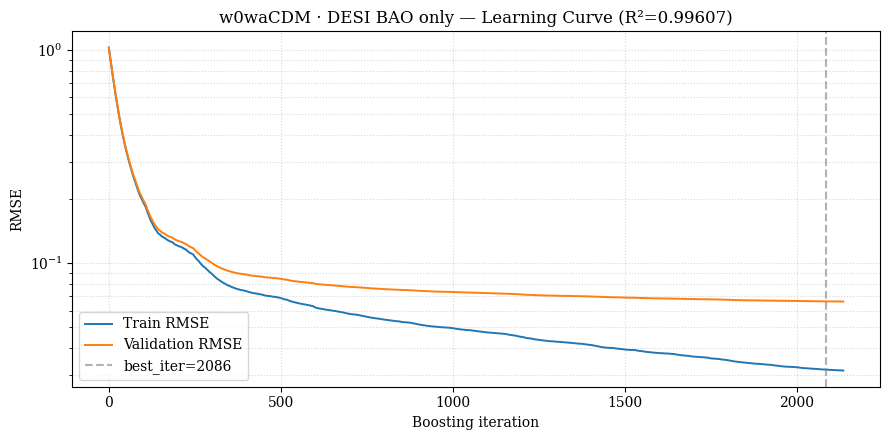

  saved: /home/aleja/repos/PhysicsML/CosmoML/outputs/paper/figures/6_3_bao_shap_beeswarm.png


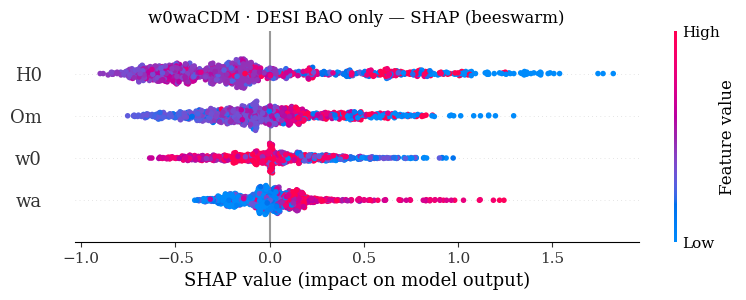

  saved: /home/aleja/repos/PhysicsML/CosmoML/outputs/paper/figures/6_3_bao_shap_bar.png


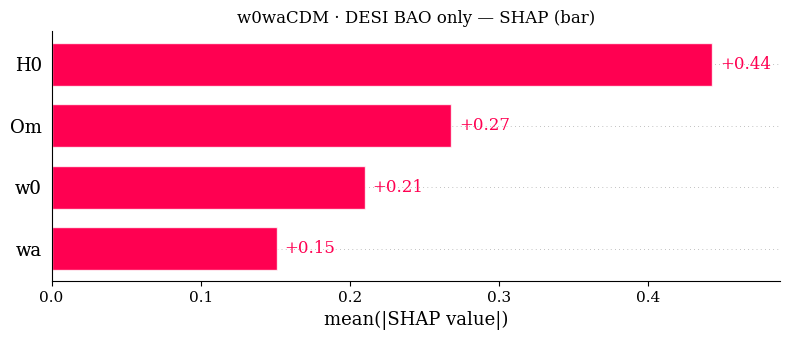

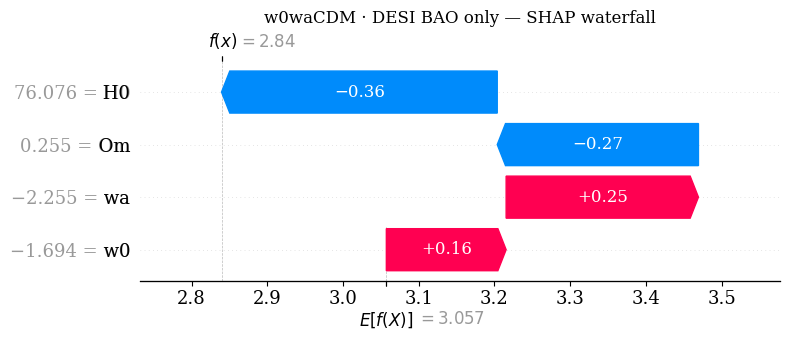

  saved: /home/aleja/repos/PhysicsML/CosmoML/outputs/paper/figures/6_3_bao_shap_Om.png


<Figure size 640x480 with 0 Axes>

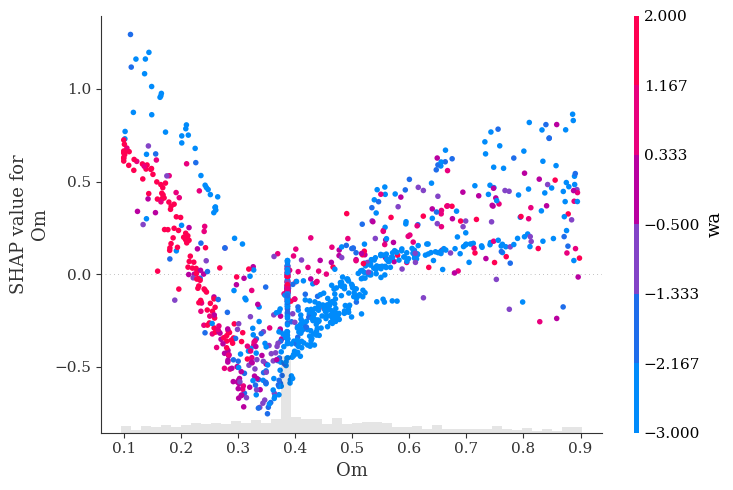

  saved: /home/aleja/repos/PhysicsML/CosmoML/outputs/paper/figures/6_3_bao_shap_H0.png


<Figure size 640x480 with 0 Axes>

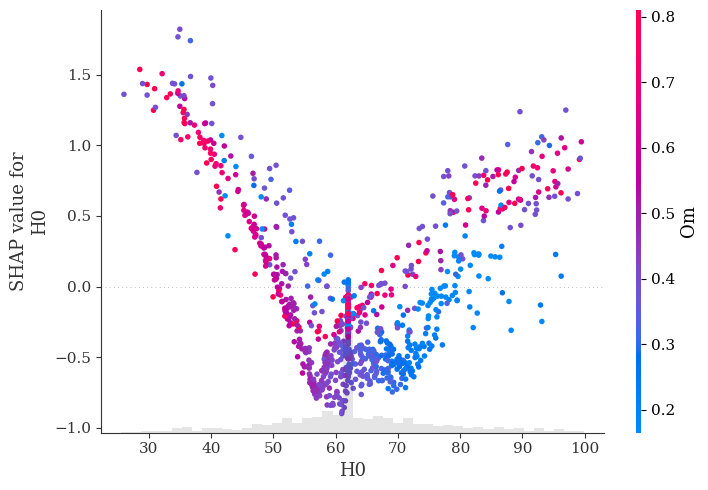

  saved: /home/aleja/repos/PhysicsML/CosmoML/outputs/paper/figures/6_3_bao_shap_w0.png


<Figure size 640x480 with 0 Axes>

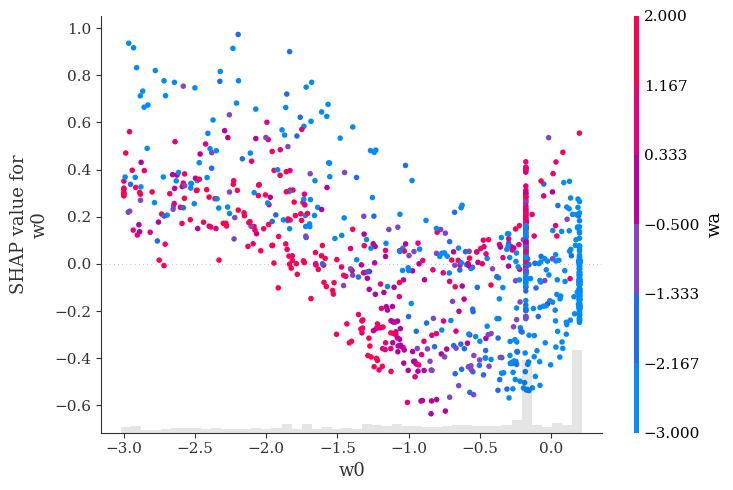

  saved: /home/aleja/repos/PhysicsML/CosmoML/outputs/paper/figures/6_3_bao_shap_wa.png


<Figure size 640x480 with 0 Axes>

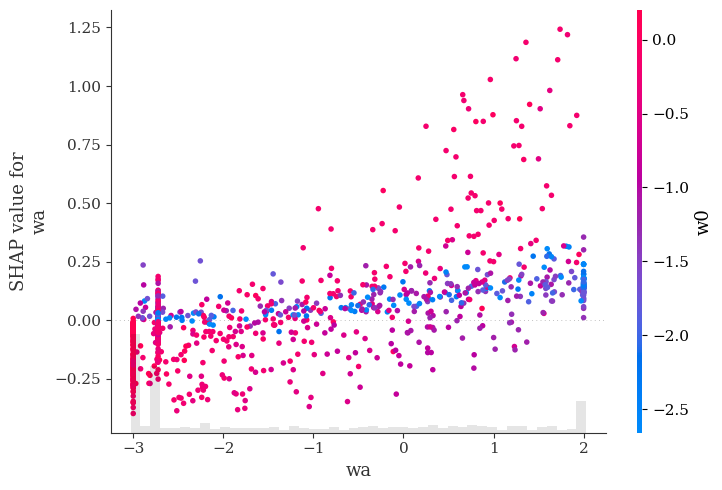

In [7]:
SECTION_3_BAO = '6_3_bao'
TITLE_3_BAO   = 'w0waCDM · DESI BAO only'

df_3_bao, REF_3_bao, COV_3_bao = build_dataset(chi2_bao_only, SECTION_3_BAO, FEATURES_4, RANGES_4, n_gaussian=150_000, gaussian_sigma_scale=3.0)
model_3_bao, info_3_bao, shap_v_3_bao, X_s_3_bao = train_and_shap(
    df_3_bao, FEATURES_4, SECTION_3_BAO, title=TITLE_3_BAO,
)


## Section 3.2 — BAO-only: ML MCMC

  [ML] Loaded chain: /home/aleja/repos/PhysicsML/CosmoML/outputs/paper/chains/6_3_bao_samples.npy  (3,994,624 samples)
Removed no burn in
  Saved: /home/aleja/repos/PhysicsML/CosmoML/outputs/paper/figures/6_3_bao_getdist.png


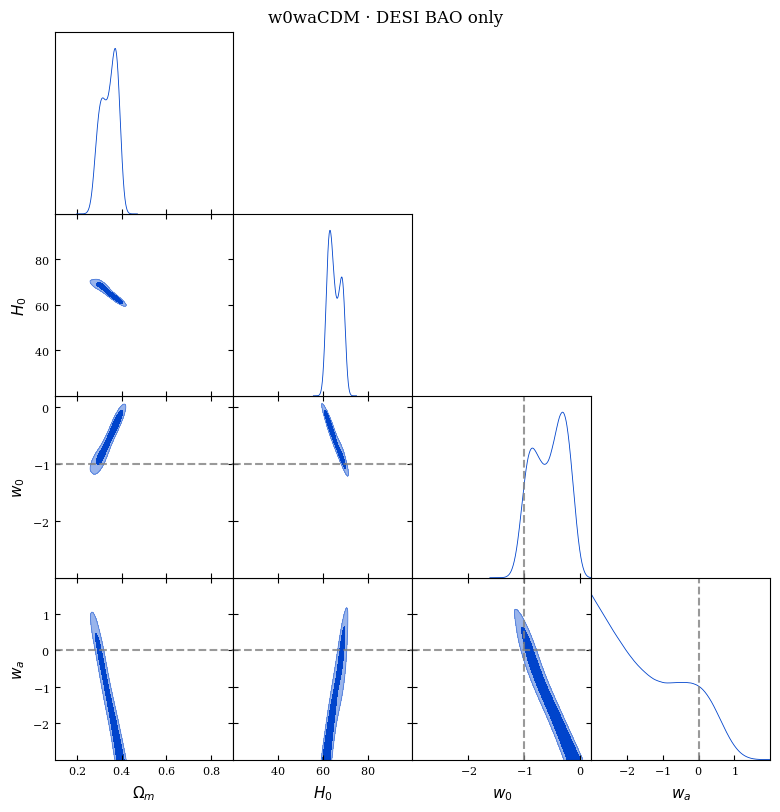

In [8]:
samples_3_bao, ml_meta_bao = run_mcmc_and_getdist(
    model_3_bao, FEATURES_4, RANGES_4, REF_3_bao, SECTION_3_BAO,
    labels=LABELS, markers=MARKERS_DE, title=TITLE_3_BAO,
    proposal_cov=COV_3_bao,
)


## Section 3.3 — 3-way ML summary getdist

In [9]:
_chain_panthbao = CHAINS_DIR / '6_2_1a_samples.npy'
_chain_full     = CHAINS_DIR / '6_2_1b_samples.npy'

if not _chain_panthbao.exists() or not _chain_full.exists():
    print('[!] Section 2 chains not found. Run run_cosmo.py (Sections 1-2) first.')
    print(f'    Expected: {_chain_panthbao}')
    print(f'    Expected: {_chain_full}')
else:
    plot_getdist_comparison(
        [samples_3_bao, np.load(_chain_panthbao), np.load(_chain_full)],
        ['BAO only', 'BAO + Pantheon+', 'BAO + Pantheon+ + CMB'],
        FEATURES_4, LABELS,
        markers=MARKERS_DE,
        title='w0waCDM — Summary ML: BAO / BAO+Pantheon+ / BAO+Pantheon++CMB',
        save_path=FIGURES_DIR / '6_3_summary_getdist.png',
        filled=[True, True, True],
        ranges=RANGES_4,
    )


[!] Section 2 chains not found. Run run_cosmo.py (Sections 1-2) first.
    Expected: /home/aleja/repos/PhysicsML/CosmoML/outputs/paper/chains/6_2_1a_samples.npy
    Expected: /home/aleja/repos/PhysicsML/CosmoML/outputs/paper/chains/6_2_1b_samples.npy


## Section 3.4 — Theory MCMC benchmark (CPU)

Exact χ² evaluated with `ProcessPoolExecutor`. Same RWMH setup as ML (1024 chains).

  [TH-CPU] Loaded: /home/aleja/repos/PhysicsML/CosmoML/outputs/paper/chains/6_3_bao_samples_theory.npy  (8,705,024 samples)
Removed no burn in
  Saved: /home/aleja/repos/PhysicsML/CosmoML/outputs/paper/figures/6_3_bao_getdist_theory.png


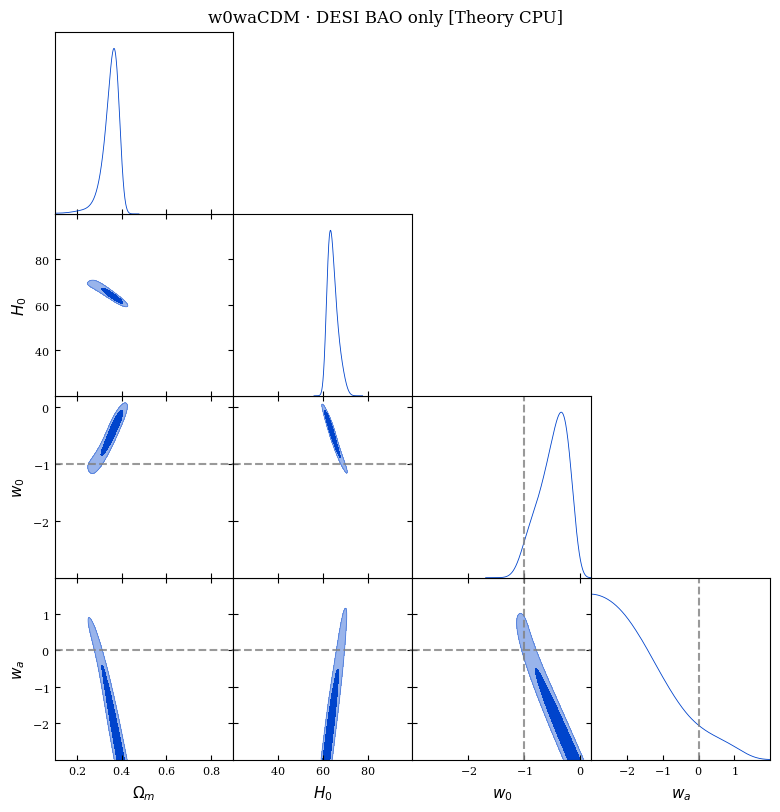

In [10]:
_, th_meta_bao = run_theory_mcmc(
    chi2_bao_only, FEATURES_4, RANGES_4, REF_3_bao, SECTION_3_BAO,
    labels=LABELS, markers=MARKERS_DE, title=TITLE_3_BAO,
    proposal_cov=COV_3_bao,
)


In [11]:
# astropy CPU + Pantheon+ omitido: serialización de panth (~22 MB)
# en cada tarea IPC provoca crashes de workers en loky.
# Usar run_theory_mcmc_numpy para este escenario.
th_meta_pb = {'cached': False, 'wall_s': None, 'n_samples': None, 'skipped': True}
print('  [TH-CPU] panth+BAO: omitido (memoria IPC) — usar numpy')

  [TH-CPU] panth+BAO: omitido (memoria IPC) — usar numpy


In [12]:
# astropy CPU + Pantheon+ omitido (mismo motivo que panth+bao).
th_meta_pbc = {'cached': False, 'wall_s': None, 'n_samples': None, 'skipped': True}
print('  [TH-CPU] panth+BAO+CMB: omitido (memoria IPC) — usar numpy')

  [TH-CPU] panth+BAO+CMB: omitido (memoria IPC) — usar numpy


## Section 3.4b — Theory MCMC (numpy vectorized)

Misma integración trapezoidal que JAX pero en numpy puro. Sin astropy, sin subprocesos — evalúa 1024 propuestas en un único batch vectorizado.

In [13]:
# Build numpy batched predict functions (once)
np_fn_bao = make_chi2_numpy_fn(panth=None,  bao=bao)
np_fn_pb  = make_chi2_numpy_fn(panth=panth, bao=bao)
np_fn_pbc = make_chi2_numpy_fn(panth=panth, bao=bao, planck_prior=True)
print('Numpy predict functions ready.')

Numpy predict functions ready.


  [TH-NP] Running MCMC (numpy batched)...
  proposal_cov: Hessian covariance accepted — skipping diagonal phase
  step   200/10000  |  66 it/s  |  ETA 148s  |  acc 0.15  |  multivar
  step   400/10000  |  67 it/s  |  ETA 144s  |  acc 0.14  |  multivar
  step   600/10000  |  66 it/s  |  ETA ≤3s  |  acc 0.13  |  τ=31.1  ESS=3298/10000  |  multivar
  step   800/10000  |  65 it/s  |  ETA ≤8s  |  acc 0.11  |  τ=80.9  ESS=3796/10000  |  multivar
  step  1000/10000  |  65 it/s  |  ETA ≤12s  |  acc 0.10  |  τ=131.4  ESS=3896/10000  |  multivar
  step  1200/10000  |  64 it/s  |  ETA ≤17s  |  acc 0.09  |  τ=180.9  ESS=3963/10000  |  multivar
  step  1400/10000  |  64 it/s  |  ETA ≤14s  |  acc 0.08  |  τ=184.5  ESS=4994/10000  |  multivar
  step  1600/10000  |  64 it/s  |  ETA ≤14s  |  acc 0.08  |  τ=205.9  ESS=5470/10000  |  multivar
  step  1800/10000  |  63 it/s  |  ETA ≤18s  |  acc 0.07  |  τ=251.3  ESS=5298/10000  |  multivar
  step  2000/10000  |  63 it/s  |  ETA ≤22s  |  acc 0.07  |  τ=298

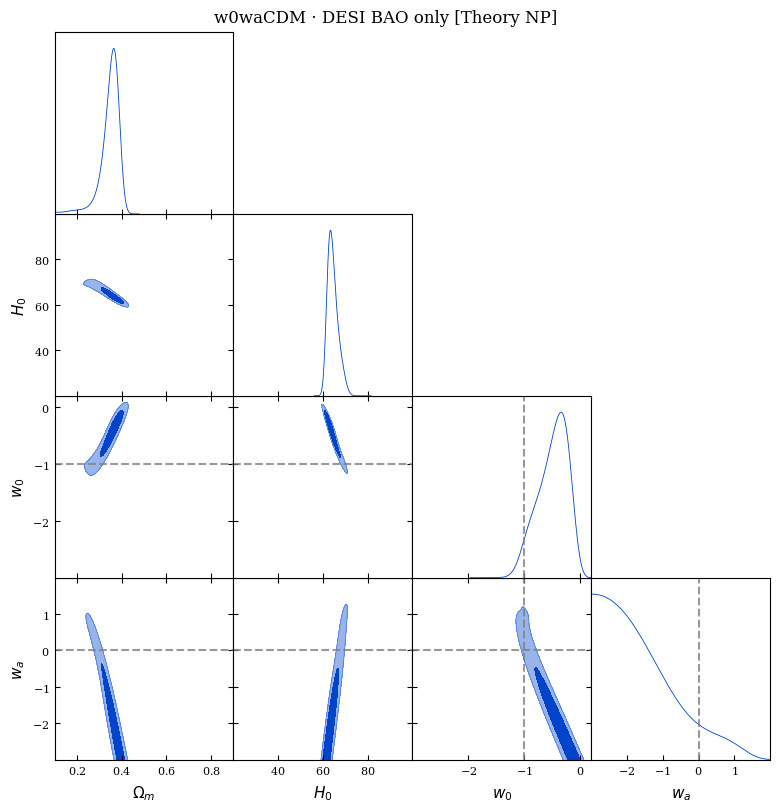

In [14]:
_, th_np_meta_bao = run_theory_mcmc_numpy(
    np_fn_bao, FEATURES_4, RANGES_4, REF_3_bao, SECTION_3_BAO,
    labels=LABELS, markers=MARKERS_DE, title=TITLE_3_BAO,
    proposal_cov=COV_3_bao,
)

  [TH-NP] Running MCMC (numpy batched)...
  step   200/10000  |  5 it/s  |  ETA 1785s  |  acc 0.05  |  diagonal
  step   400/10000  |  6 it/s  |  ETA 1732s  |  acc 0.06  |  diagonal
  step   600/10000  |  6 it/s  |  ETA ≤25s  |  acc 0.08  |  τ=24.6  ESS=4171/10000  |  multivar
  step   800/10000  |  6 it/s  |  ETA ≤34s  |  acc 0.10  |  τ=50.1  ESS=6134/10000  |  multivar
  step  1000/10000  |  6 it/s  |  ETA ≤17s  |  acc 0.12  |  τ=60.9  ESS=8405/10000  |  multivar
  step  1200/10000  |  6 it/s  |  ETA ≤56s  |  acc 0.12  |  τ=104.1  ESS=6885/10000  |  multivar
  step  1400/10000  |  6 it/s  |  ETA ≤0s  |  acc 0.13  |  τ=81.0  ESS=11379/10000  |  multivar
  done: 249.6s  |  6 it/s  |  acceptance 0.130  |  multivariate proposal
  flat chain: 922,624 samples (1024 chains × 901 steps)  |  τ_max=81.0  |  ESS=11392
  [TH-NP] Done: 249.8s  (922,624 samples)
Removed no burn in
  Saved: /home/aleja/repos/PhysicsML/CosmoML/outputs/paper/figures/6_2_1a_getdist_theory_np.png


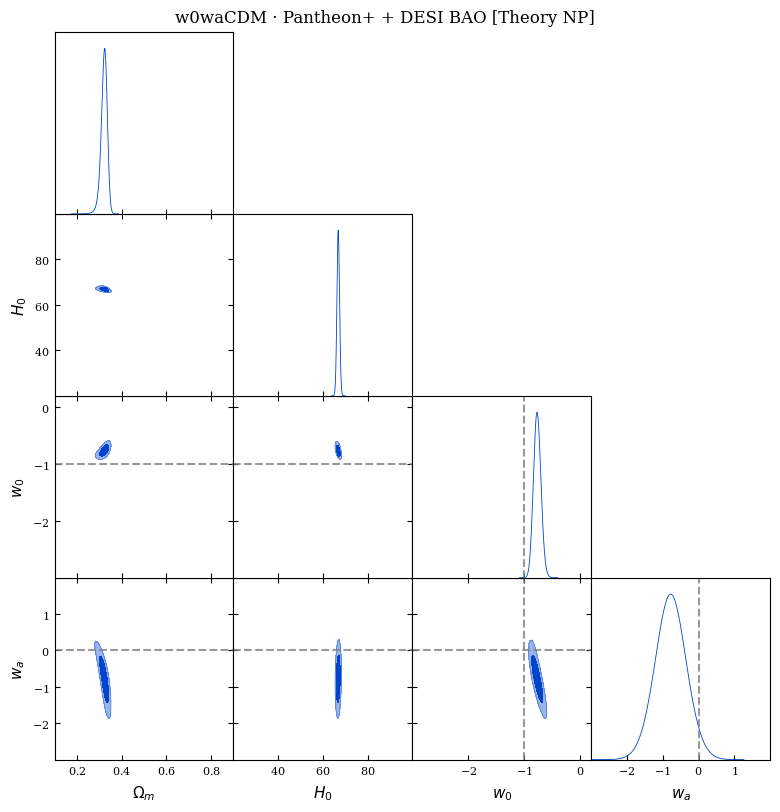

In [15]:
_, th_np_meta_pb = run_theory_mcmc_numpy(
    np_fn_pb, FEATURES_4, RANGES_4, REF_2_1a, SECTION_2_1A,
    labels=LABELS, markers=MARKERS_DE, title=TITLE_2_1A,
)

  [TH-NP] Running MCMC (numpy batched)...
  step   200/10000  |  6 it/s  |  ETA 1751s  |  acc 0.04  |  diagonal
  step   400/10000  |  6 it/s  |  ETA 1712s  |  acc 0.04  |  diagonal
  step   600/10000  |  6 it/s  |  ETA ≤31s  |  acc 0.06  |  τ=28.3  ESS=3622/10000  |  multivar
  step   800/10000  |  6 it/s  |  ETA ≤45s  |  acc 0.08  |  τ=56.8  ESS=5413/10000  |  multivar
  step  1000/10000  |  6 it/s  |  ETA ≤33s  |  acc 0.09  |  τ=70.0  ESS=7316/10000  |  multivar
  step  1200/10000  |  6 it/s  |  ETA ≤18s  |  acc 0.10  |  τ=82.3  ESS=8714/10000  |  multivar
  step  1400/10000  |  6 it/s  |  ETA ≤0s  |  acc 0.11  |  τ=66.5  ESS=13855/10000  |  multivar
  done: 248.7s  |  6 it/s  |  acceptance 0.105  |  multivariate proposal
  flat chain: 922,624 samples (1024 chains × 901 steps)  |  τ_max=66.5  |  ESS=13871
  [TH-NP] Done: 249.0s  (922,624 samples)
Removed no burn in
  Saved: /home/aleja/repos/PhysicsML/CosmoML/outputs/paper/figures/6_2_1b_getdist_theory_np.png


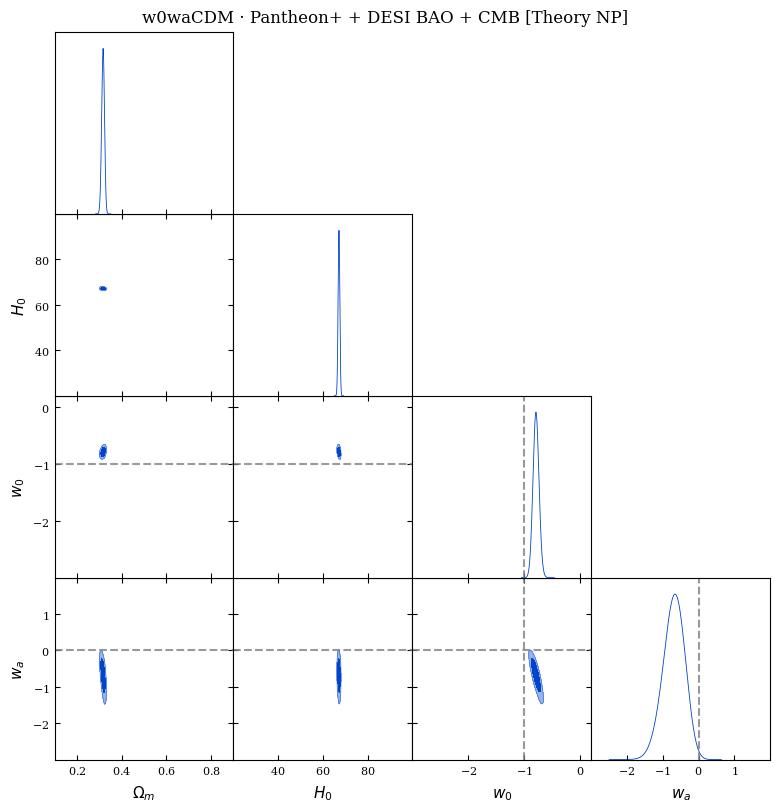

In [16]:
_, th_np_meta_pbc = run_theory_mcmc_numpy(
    np_fn_pbc, FEATURES_4, RANGES_4, REF_2_1b, SECTION_2_1B,
    labels=LABELS, markers=MARKERS_DE, title=TITLE_2_1B,
)

In [17]:
# 3-way theory summary
_th_bao = CHAINS_DIR / f'{SECTION_3_BAO}_samples_theory.npy'
_th_pb  = CHAINS_DIR / f'{SECTION_2_1A}_samples_theory.npy'
_th_pbc = CHAINS_DIR / f'{SECTION_2_1B}_samples_theory.npy'

if all(p.exists() for p in [_th_bao, _th_pb, _th_pbc]):
    plot_getdist_comparison(
        [np.load(_th_bao), np.load(_th_pb), np.load(_th_pbc)],
        ['BAO only', 'BAO + Pantheon+', 'BAO + Pantheon+ + CMB'],
        FEATURES_4, LABELS,
        markers=MARKERS_DE,
        title='w0waCDM — Summary Theory CPU',
        save_path=FIGURES_DIR / '6_3_summary_getdist_theory.png',
        filled=[True, True, True], ranges=RANGES_4,
    )


## Section 3.5 — Theory MCMC benchmark (JAX/GPU)

Exact χ² vectorized via JAX `vmap` on GPU. Skip if JAX not installed.

Compiling JAX functions (warm-up)...
JAX JIT ready.
  [TH-GPU] Running MCMC (JAX/GPU)...
  step   200/10000  |  2 it/s  |  ETA 5036s  |  acc 0.05  |  diagonal
  step   400/10000  |  3 it/s  |  ETA 2807s  |  acc 0.07  |  diagonal
  step   600/10000  |  4 it/s  |  ETA ≤48s  |  acc 0.09  |  τ=30.1  ESS=3397/10000  |  multivar
  step   800/10000  |  5 it/s  |  ETA ≤83s  |  acc 0.12  |  τ=76.1  ESS=4038/10000  |  multivar
  step  1000/10000  |  7 it/s  |  ETA ≤129s  |  acc 0.13  |  τ=138.9  ESS=3686/10000  |  multivar
  step  1200/10000  |  8 it/s  |  ETA ≤119s  |  acc 0.14  |  τ=167.7  ESS=4274/10000  |  multivar
  step  1400/10000  |  9 it/s  |  ETA ≤56s  |  acc 0.15  |  τ=145.1  ESS=6352/10000  |  multivar
  step  1600/10000  |  10 it/s  |  ETA ≤123s  |  acc 0.16  |  τ=243.5  ESS=4627/10000  |  multivar
  step  1800/10000  |  12 it/s  |  ETA ≤141s  |  acc 0.16  |  τ=301.7  ESS=4412/10000  |  multivar
  step  2000/10000  |  13 it/s  |  ETA ≤176s  |  acc 0.16  |  τ=384.9  ESS=3990/10000  |

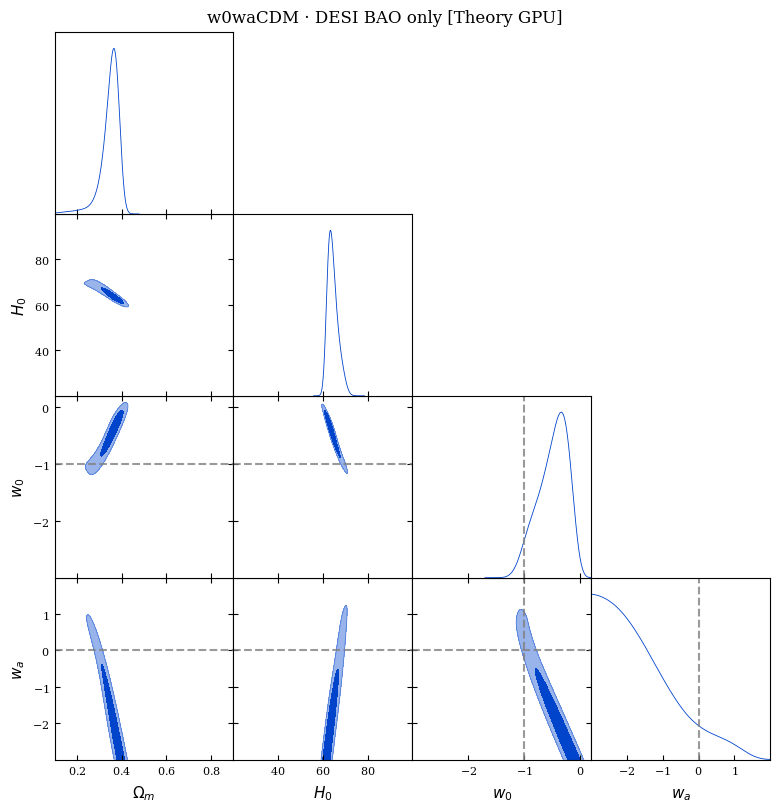

  [TH-GPU] Running MCMC (JAX/GPU)...
  step   200/10000  |  25 it/s  |  ETA 391s  |  acc 0.02  |  diagonal
  step   400/10000  |  47 it/s  |  ETA 206s  |  acc 0.01  |  diagonal
  step   600/10000  |  11 it/s  |  ETA ≤14s  |  acc 0.01  |  τ=26.1  ESS=3917/10000  |  multivar
  step   800/10000  |  13 it/s  |  ETA ≤42s  |  acc 0.01  |  τ=87.8  ESS=3498/10000  |  multivar
  step  1000/10000  |  15 it/s  |  ETA ≤65s  |  acc 0.01  |  τ=149.6  ESS=3422/10000  |  multivar
  step  1200/10000  |  14 it/s  |  ETA ≤94s  |  acc 0.01  |  τ=210.1  ESS=3411/10000  |  multivar
  step  1400/10000  |  14 it/s  |  ETA ≤110s  |  acc 0.00  |  τ=253.3  ESS=3638/10000  |  multivar
  step  1600/10000  |  16 it/s  |  ETA ≤125s  |  acc 0.00  |  τ=320.0  ESS=3520/10000  |  multivar
  step  1800/10000  |  17 it/s  |  ETA ≤145s  |  acc 0.00  |  τ=383.5  ESS=3471/10000  |  multivar
  step  2000/10000  |  17 it/s  |  ETA ≤156s  |  acc 0.00  |  τ=431.9  ESS=3556/10000  |  multivar
  step  2200/10000  |  17 it/s  |  ET

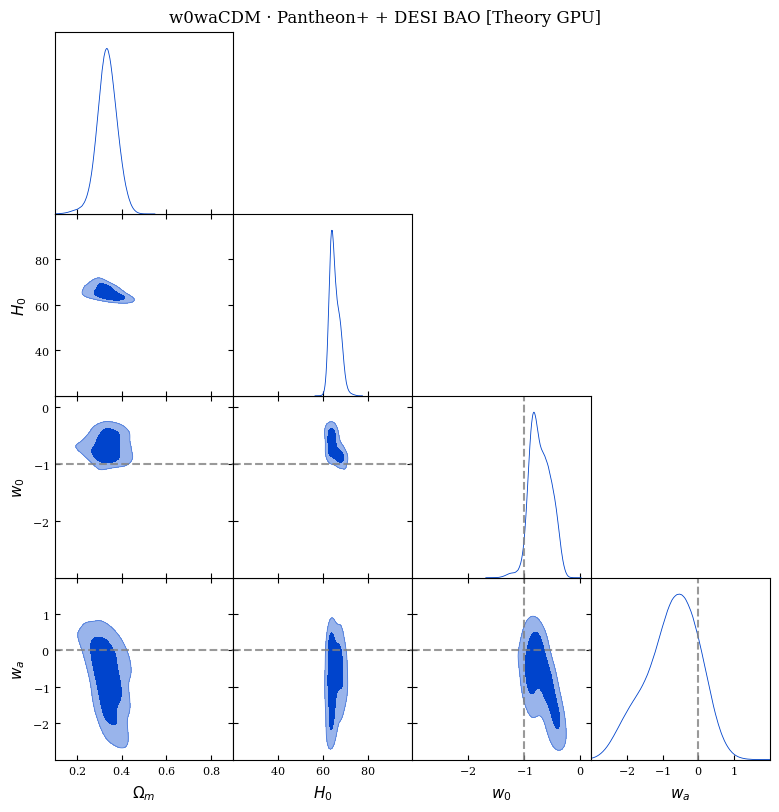

  [TH-GPU] Running MCMC (JAX/GPU)...
  step   200/10000  |  138 it/s  |  ETA 71s  |  acc 0.02  |  diagonal
  step   400/10000  |  193 it/s  |  ETA 50s  |  acc 0.01  |  diagonal
  step   600/10000  |  121 it/s  |  ETA ≤2s  |  acc 0.01  |  τ=29.8  ESS=3432/10000  |  multivar
  step   800/10000  |  144 it/s  |  ETA ≤4s  |  acc 0.01  |  τ=85.7  ESS=3586/10000  |  multivar
  step  1000/10000  |  161 it/s  |  ETA ≤5s  |  acc 0.01  |  τ=141.9  ESS=3607/10000  |  multivar
  step  1200/10000  |  159 it/s  |  ETA ≤8s  |  acc 0.01  |  τ=203.4  ESS=3525/10000  |  multivar
  step  1400/10000  |  156 it/s  |  ETA ≤10s  |  acc 0.00  |  τ=257.3  ESS=3581/10000  |  multivar
  step  1600/10000  |  166 it/s  |  ETA ≤12s  |  acc 0.00  |  τ=311.0  ESS=3622/10000  |  multivar
  step  1800/10000  |  173 it/s  |  ETA ≤14s  |  acc 0.00  |  τ=375.9  ESS=3541/10000  |  multivar
  step  2000/10000  |  179 it/s  |  ETA ≤15s  |  acc 0.00  |  τ=434.1  ESS=3538/10000  |  multivar
  step  2200/10000  |  184 it/s  |  E

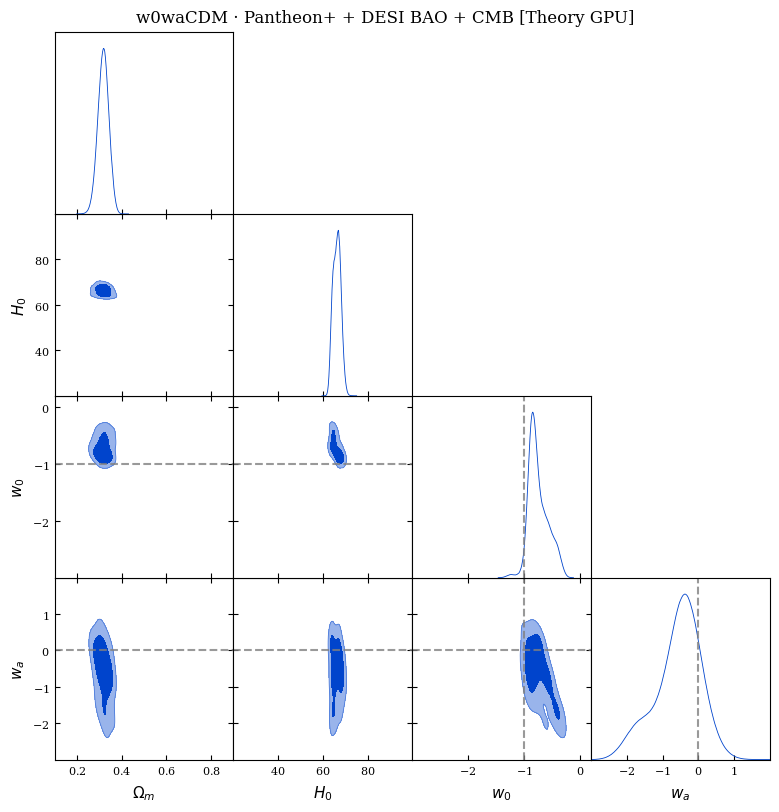

Removed no burn in
Removed no burn in
Removed no burn in
  Saved: /home/aleja/repos/PhysicsML/CosmoML/outputs/paper/figures/6_3_summary_getdist_theory_gpu.png


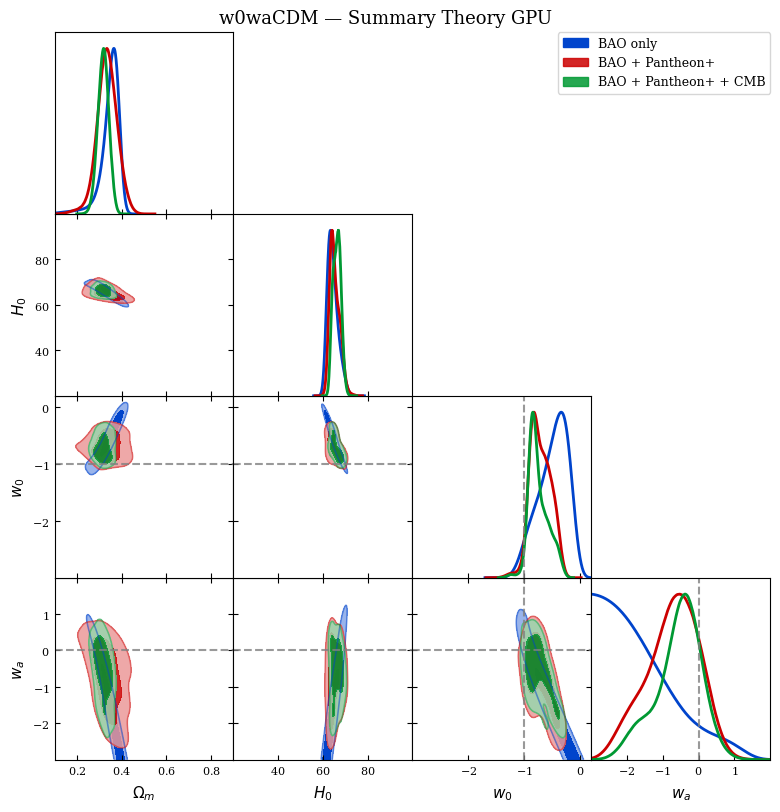

In [18]:
th_gpu_meta_bao = th_gpu_meta_pb = th_gpu_meta_pbc = None

if not _JAX_THEORY_OK:
    print('[!] JAX not available. Install with: pip install jax[cuda]')
else:
    print('Compiling JAX functions (warm-up)...')
    gpu_fn_bao = _make_chi2_gpu_fn(panth=None,  bao=bao)
    gpu_fn_pb  = _make_chi2_gpu_fn(panth=panth, bao=bao)
    gpu_fn_pbc = _make_chi2_gpu_fn(panth=panth, bao=bao, planck_prior=True)
    print('JAX JIT ready.')

    _, th_gpu_meta_bao = run_theory_mcmc_gpu(
        gpu_fn_bao, FEATURES_4, RANGES_4, REF_3_bao, SECTION_3_BAO,
        labels=LABELS, markers=MARKERS_DE, title=TITLE_3_BAO,
    )
    _, th_gpu_meta_pb = run_theory_mcmc_gpu(
        gpu_fn_pb, FEATURES_4, RANGES_4, REF_2_1a, SECTION_2_1A,
        labels=LABELS, markers=MARKERS_DE, title=TITLE_2_1A,
    )
    _, th_gpu_meta_pbc = run_theory_mcmc_gpu(
        gpu_fn_pbc, FEATURES_4, RANGES_4, REF_2_1b, SECTION_2_1B,
        labels=LABELS, markers=MARKERS_DE, title=TITLE_2_1B,
    )

    # 3-way theory GPU summary
    _tg_bao = CHAINS_DIR / f'{SECTION_3_BAO}_samples_theory_gpu.npy'
    _tg_pb  = CHAINS_DIR / f'{SECTION_2_1A}_samples_theory_gpu.npy'
    _tg_pbc = CHAINS_DIR / f'{SECTION_2_1B}_samples_theory_gpu.npy'
    if all(p.exists() for p in [_tg_bao, _tg_pb, _tg_pbc]):
        plot_getdist_comparison(
            [np.load(_tg_bao), np.load(_tg_pb), np.load(_tg_pbc)],
            ['BAO only', 'BAO + Pantheon+', 'BAO + Pantheon+ + CMB'],
            FEATURES_4, LABELS,
            markers=MARKERS_DE,
            title='w0waCDM — Summary Theory GPU',
            save_path=FIGURES_DIR / '6_3_summary_getdist_theory_gpu.png',
            filled=[True, True, True], ranges=RANGES_4,
        )


## Section 3.6 — Dataset generation: GPU vs CPU

JAX batch evaluation vs `ProcessPoolExecutor` (5 k sample → extrapolated to full dataset).

In [19]:
ds_gpu_meta_bao = ds_gpu_meta_pb = ds_gpu_meta_pbc = None

if not _JAX_THEORY_OK:
    print('[!] JAX not available — skipping dataset GPU benchmark')
else:
    _, ds_gpu_meta_bao = build_dataset_gpu(
        gpu_fn_bao, chi2_bao_only, SECTION_3_BAO, FEATURES_4, RANGES_4, REF_3_bao,
    )
    _, ds_gpu_meta_pb = build_dataset_gpu(
        gpu_fn_pb, chi2_panth_bao, SECTION_2_1A, FEATURES_4, RANGES_4, REF_2_1a,
    )
    _, ds_gpu_meta_pbc = build_dataset_gpu(
        gpu_fn_pbc, chi2_panth_bao_cmb, SECTION_2_1B, FEATURES_4, RANGES_4, REF_2_1b,
    )

    print('\n' + '-' * 86)
    print(f'{"scenario":<22}{"gpu [s]":>10}{"cpu×5k→extrap":>16}'
          f'{"speedup":>10}{"max|Δχ²|":>12}{"mean|Δχ²|":>12}')
    print('-' * 86)
    for name, m in [
        ('bao_only',      ds_gpu_meta_bao),
        ('panth_bao',     ds_gpu_meta_pb),
        ('panth_bao_cmb', ds_gpu_meta_pbc),
    ]:
        if m is None: print(f'  {name}'); continue
        cmp = m.get('comparison', {})
        gpu_s = f"{m['gpu_wall_s']:.1f}s" if m['gpu_wall_s'] else 'cached'
        cpu_s = f"{m['cpu_sample_s']:.1f}s→{m['cpu_extrap_s']:.0f}s"
        spd   = f"{m['speedup']:.1f}x" if m['speedup'] else '-'
        maxd  = f"{cmp['max_abs_diff']:.4f}" if cmp.get('max_abs_diff') else '-'
        meand = f"{cmp['mean_abs_diff']:.4f}" if cmp.get('mean_abs_diff') else '-'
        print(f'{name:<22}{gpu_s:>10}{cpu_s:>16}{spd:>10}{maxd:>12}{meand:>12}')
    print('-' * 86)


  [DS-GPU]  Evaluando 200,000 pts (JAX GPU batch)...
  [DS-GPU]  0.94s  (213,743 pts/s)
  [DS-CPU]  Timing sample 5,000 pts (23 cores)...
  [DS-CPU]  4.0s / 5,000 pts → extrap full: 160s
  [DS-SPD]  Speedup GPU vs CPU (extrap): 170.9x
  [DS-CMP]  max|Δχ²|=569.0738 | mean|Δχ²|=3.6707
  [DS-GPU]  Evaluando 200,000 pts (JAX GPU batch)...
  [DS-GPU]  65.85s  (3,037 pts/s)
  [DS-CPU]  Timing sample 5,000 pts (23 cores)...
  [DS-CPU]  110.1s / 5,000 pts → extrap full: 4402s
  [DS-SPD]  Speedup GPU vs CPU (extrap): 66.8x
  [DS-GPU]  Evaluando 200,000 pts (JAX GPU batch)...
  [DS-GPU]  1.09s  (183,513 pts/s)
  [DS-CPU]  Timing sample 5,000 pts (23 cores)...
  [DS-CPU]  107.5s / 5,000 pts → extrap full: 4301s
  [DS-SPD]  Speedup GPU vs CPU (extrap): 3946.2x

--------------------------------------------------------------------------------------
scenario                 gpu [s]   cpu×5k→extrap   speedup    max|Δχ²|   mean|Δχ²|
----------------------------------------------------------------------

## Timings — summary table & JSON

In [20]:
def _speedup(ml_m, th_m):
    w_ml = (ml_m or {}).get('wall_s')
    w_th = (th_m or {}).get('wall_s')
    return round(w_th / w_ml, 2) if (w_ml and w_th) else None

def _skip(m):
    return m if m is not None else {'wall_s': None, 'n_samples': None, 'cached': True}

# ml_meta_pb and ml_meta_pbc are cached from run_cosmo.py (Section 2)
_n_pb  = len(np.load(_chain_panthbao)) if _chain_panthbao.exists() else None
_n_pbc = len(np.load(_chain_full))     if _chain_full.exists()     else None
ml_meta_pb  = {'cached': True, 'wall_s': None, 'n_samples': _n_pb}
ml_meta_pbc = {'cached': True, 'wall_s': None, 'n_samples': _n_pbc}

timings = {
    'ml_engine':          'RWMH 1024 chains, XGBoost GPU booster (LogChi2)',
    'theory_cpu_engine':  'RWMH 1024 chains, ProcessPoolExecutor exact chi2',
    'theory_gpu_engine':  'RWMH 1024 chains, JAX vmap GPU exact chi2',
    'dataset_gpu_engine': 'JAX vmap GPU batch, same sampling as CPU (seed=42)',
    'common': {'n_chains': 1024, 'n_steps_cap': 10_000, 'burn_in': 500,
               'seed': 42, 'ess_target': 10_000,
               'theory_cpu_note': 'panth scenarios use 32 chains x 2000 steps'},
    'runs': {
        'bao_only': {
            'ml':          ml_meta_bao,
            'theory_np':   th_np_meta_bao,
            'theory_cpu':  th_meta_bao,
            'theory_gpu':  _skip(th_gpu_meta_bao),
            'dataset_gpu': ds_gpu_meta_bao,
            'speedup_cpu_vs_ml':  _speedup(ml_meta_bao, th_meta_bao),
            'speedup_gpu_vs_ml':  _speedup(ml_meta_bao, _skip(th_gpu_meta_bao)),
            'speedup_gpu_vs_cpu': _speedup(_skip(th_gpu_meta_bao), th_meta_bao),
        },
        'panth_bao': {
            'ml':          ml_meta_pb,
            'theory_np':   th_np_meta_pb,
            'theory_cpu':  th_meta_pb,
            'theory_gpu':  _skip(th_gpu_meta_pb),
            'dataset_gpu': ds_gpu_meta_pb,
            'speedup_cpu_vs_ml':  _speedup(ml_meta_pb, th_meta_pb),
            'speedup_gpu_vs_ml':  _speedup(ml_meta_pb, _skip(th_gpu_meta_pb)),
            'speedup_gpu_vs_cpu': _speedup(_skip(th_gpu_meta_pb), th_meta_pb),
        },
        'panth_bao_cmb': {
            'ml':          ml_meta_pbc,
            'theory_np':   th_np_meta_pbc,
            'theory_cpu':  th_meta_pbc,
            'theory_gpu':  _skip(th_gpu_meta_pbc),
            'dataset_gpu': ds_gpu_meta_pbc,
            'speedup_cpu_vs_ml':  _speedup(ml_meta_pbc, th_meta_pbc),
            'speedup_gpu_vs_ml':  _speedup(ml_meta_pbc, _skip(th_gpu_meta_pbc)),
            'speedup_gpu_vs_cpu': _speedup(_skip(th_gpu_meta_pbc), th_meta_pbc),
        },
    },
}

timings_path = PAPER_DIR / 'timings.json'
with open(timings_path, 'w') as f:
    json.dump(timings, f, indent=2)
print(f'Timings saved: {timings_path}\n')

def _fs(v): return f'{v:.1f}s' if v is not None else 'cached'
def _fsp(v): return f'{v:.1f}x' if v is not None else '-'

rows = [
    ('bao_only',      ml_meta_bao, th_meta_bao, th_np_meta_bao, th_gpu_meta_bao),
    ('panth_bao',     ml_meta_pb,  th_meta_pb,  th_np_meta_pb,  th_gpu_meta_pb),
    ('panth_bao_cmb', ml_meta_pbc, th_meta_pbc, th_np_meta_pbc, th_gpu_meta_pbc),
]
print('-' * 90)
print(f'{"section":<18}{"ml [s]":>10}{"th-cpu [s]":>12}{"th-np [s]":>11}{"th-gpu [s]":>12}'
      f'{"×cpu/ml":>9}{"×np/ml":>8}{"×gpu/ml":>9}')
print('-' * 90)
for name, ml_m, th_m, np_m, tg_m in rows:
    tg = _skip(tg_m)
    print(f'{name:<18}'
          f'{_fs(ml_m["wall_s"]):>10}'
          f'{_fs(th_m["wall_s"]):>12}'
          f'{_fs(np_m["wall_s"]):>11}'
          f'{_fs(tg["wall_s"]):>12}'
          f'{_fsp(_speedup(ml_m, th_m)):>9}'
          f'{_fsp(_speedup(ml_m, np_m)):>8}'
          f'{_fsp(_speedup(ml_m, tg)):>9}')
print('-' * 90)

Timings saved: /home/aleja/repos/PhysicsML/CosmoML/outputs/paper/timings.json

------------------------------------------------------------------------------------------
section               ml [s]  th-cpu [s]  th-np [s]  th-gpu [s]  ×cpu/ml  ×np/ml  ×gpu/ml
------------------------------------------------------------------------------------------
bao_only              cached      cached     135.1s      283.1s        -       -        -
panth_bao             cached      cached     249.8s      306.5s        -       -        -
panth_bao_cmb         cached      cached     249.0s      143.6s        -       -        -
------------------------------------------------------------------------------------------
